# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Keywords and Keyphrase Extraction Implementation**
    * Setup Environments
    * Data Loading
    * Data Visualization (EDA)
    * Data Preprocessing
    * Model Training (TextRank)
    * TextRank vs. SGRank Comparison
        * SGRank
        * TextRank Vs. SGRank Algorithm
        * TextRank Algorithm
        * SGRank Algorithm
        * TextRank Vs. SGRank Result Comparison
* **Conclusion**
* **References**

# Introduction

Keyword and keyphrase extraction is a fundamental task in natural language processing (NLP) that involves identifying the most important words and multi-word phrases that capture the core topics and meaning of a document. Graph-based unsupervised methods, such as TextRank and its variants, have become popular due to their ability to leverage word co-occurrence relationships without requiring labeled training data. This implementation demonstrates the application of TextRank and SGRank algorithms from the textacy library for extracting keyphrases from a dataset of 100 arXiv paper abstracts. The process includes data loading, preprocessing with spaCy and NLTK, keyphrase extraction, and comparative visualization using knowledge graphs to highlight differences between the algorithms.

# Objective
The objective of this project is to implement and compare unsupervised graph-based keyphrase extraction techniques on scientific abstracts, specifically using TextRank (pure PageRank centrality) and SGRank (which incorporates additional statistical features like position and TF-IDF weighting). The project aims to:

- Load and preprocess a sample of arXiv paper abstracts for analysis.
- Apply TextRank and SGRank to extract the top keyphrases from each abstract.
- Visualize extracted keyphrases through word co-occurrence graphs, highlighting important terms.
- Compare the performance and outputs of TextRank versus SGRank on the same texts, including quantitative score differences and qualitative differences in highlighted terms.

This serves as an educational demonstration of how graph-based ranking can effectively summarize scientific documents and reveals subtle improvements offered by enhanced variants like SGRank.

# Pipeline Overview

The keyphrase extraction pipeline follows a structured sequence of steps to transform raw abstracts into meaningful keyphrases and comparative insights:

**Data Loading and Sampling:**
- Load the arXiv dataset from CSV and sample 100 abstracts for efficient processing.

**Data Exploration and Visualization:**
- Display random abstracts and identify the longest one to understand text length variation.
- Print segmented and tokenized examples for inspection.

**Data Preprocessing:**

- Perform sentence segmentation using NLTK.
- Apply word tokenization and part-of-speech (POS) tagging to prepare text for graph-based modeling.

**TextRank Modeling:**

- Process all abstracts using TextRank to extract top-5 keyphrases.
- Display results on random samples.

**Algorithm Comparison (TextRank vs. SGRank):**

- Apply both TextRank and SGRank on a selected sample abstract.
- Build word co-occurrence graphs using NetworkX.
- Visualize individual graphs with highlighted keywords for each algorithm.
- Compare top-10 ranked keyphrases with scores and create side-by-side graph visualizations.

**Result Analysis:**

- Present merged score tables and combined visualizations to evaluate differences in keyword ranking and emphasis.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">titles</td>
    <td class="tg-7zrl">The title of the arXiv research paper. Includes approximately 39,000 unique values across the dataset.</td>
    <td class="tg-7zrl">Text/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">summaries</td>
    <td class="tg-7zrl">The abstract or summary of the arXiv paper. These provide a concise overview of the research and findings.</td>
    <td class="tg-7zrl">Text/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">terms</td>
    <td class="tg-7zrl">Categorical tags representing the arXiv research areas (e.g., Computer Vision, Machine Learning).</td>
    <td class="tg-7zrl">List/Categorical</td>
  </tr>
</tbody>
</table>

[**Dataset Link**](https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts)

# Approach

The overall approach demonstrates a lightweight, unsupervised pipeline suitable for summarizing large collections of scientific texts, with clear evidence that enhanced ranking (SGRank) can improve keyphrase quality over vanilla TextRank. This implementation follows a systematic unsupervised methodology centered on graph-based ranking algorithms from the textacy library, applied to scientific abstracts. The process is divided into key phases:

**Data Loading and Exploration Approach**

The arXiv dataset is loaded using pandas, and a random sample of 100 abstracts is selected to balance computational efficiency with representative diversity. Initial exploration includes displaying random full abstracts and identifying the longest one by word count to assess variability in document length. This step ensures familiarity with the domain-specific language typical of computer science and machine learning papers.

**Preprocessing Pipeline Approach**

Preprocessing focuses on structuring text for graph-based algorithms:
- Sentence Segmentation: NLTK's sent_tokenize splits each abstract into sentences, enabling granular processing.
- Word Tokenization: Sentences are further tokenized into words using word_tokenize.
- POS Tagging: `nltk.pos_tag` is applied to identify grammatical roles, supporting downstream filtering (though primarily used here for inspection).

These steps produce clean, structured representations while preserving content words essential for co-occurrence analysis.

**Keyphrase Extraction Approach**

The core extraction leverages textacy's implementations:
- `TextRank`: Uses pure PageRank on a word co-occurrence graph (window_size=5), ranking lemmatized candidate phrases (filtered to NOUN, PROPN, ADJ). Top-5 keyphrases are extracted per abstract.
- `SGRank`: Enhances TextRank by incorporating statistical signals (e.g., term position, TF-IDF-like weighting), often yielding more contextually prioritized phrases.

Extraction is applied both globally (across all 100 abstracts) and on individual samples for detailed comparison.

**Visualization and Comparison Approach**

Interpretability is achieved through knowledge graphs:

- A word co-occurrence graph is built using NetworkX, with edges between consecutive non-stop lemmatized words.
- Nodes are sized by degree and colored (orange/salmon) if part of extracted keyphrases.
- Individual graphs are plotted for TextRank and SGRank on the same text.
- Side-by-side visualizations and score tables compare the algorithms directly.

This reveals how SGRank often assigns higher scores to domain-relevant multi-word phrases (e.g., model names) due to its additional statistical biasing, while TextRank relies purely on graph centrality.

# Keywords and Keyphrase Extraction Implementation

## Setup Environments

**Packages Installation**

Installs textacy and downloads the small English spaCy model (`en_core_web_sm`) needed for linguistic processing.

In [25]:
%%capture
!pip install -q textacy
!python -m spacy download en_core_web_sm -q

**Import Libraries**

Imports essential libraries (`pandas, spaCy, textacy, NLTK, NetworkX, matplotlib`). Downloads required NLTK data (punkt tokenizer, POS tagger) and loads the spaCy English model.

In [26]:
import pandas as pd
import spacy
import textacy
import nltk
import networkx as nx
import matplotlib.pyplot as plt
from textacy.extract import keyterms

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## Data Loading

Reads the full arXiv abstracts dataset from CSV. Randomly samples 100 abstracts (fixed seed for reproducibility) and keeps only the summaries (abstract text) column for further processing.

In [3]:
df = pd.read_csv('/kaggle/input/arxiv-paper-abstracts/arxiv_data.csv')
df = df.sample(n=100, random_state=42)
df

,titles,summaries,terms
29096,Enforcing geometric constraints of virtual nor...,Monocular depth prediction plays a crucial rol...,['cs.CV']
2638,Chart Auto-Encoders for Manifold Structured Data,Deep generative models have made tremendous ad...,"['cs.LG', 'stat.ML']"
28705,SASO: Joint 3D Semantic-Instance Segmentation ...,We propose a novel 3D point cloud segmentation...,"['cs.CV', 'cs.RO']"
10009,Revisiting knowledge transfer for training obj...,We propose to revisit knowledge transfer for t...,['cs.CV']
42938,Self-attention based BiLSTM-CNN classifier for...,Heart Failure is a major component of healthca...,"['cs.LG', 'cs.CV', 'eess.IV']"
...,...,...,...
9955,Domain Adaptation for Infection Prediction fro...,Acute respiratory infections have epidemic and...,"['cs.LG', 'q-bio.PE', 'q-bio.QM', 'stat.ML']"
19223,Discriminative Latent Semantic Graph for Video...,Video captioning aims to automatically generat...,['cs.CV']
3834,Unsupervised Representation Learning with Deep...,"In recent years, supervised learning with conv...","['cs.LG', 'cs.CV']"
12248,"R-PointHop: A Green, Accurate and Unsupervised...",Inspired by the recent PointHop classification...,['cs.CV']


In [4]:
df = df["summaries"]
df

29096    Monocular depth prediction plays a crucial rol...
2638     Deep generative models have made tremendous ad...
28705    We propose a novel 3D point cloud segmentation...
10009    We propose to revisit knowledge transfer for t...
42938    Heart Failure is a major component of healthca...
                               ...                        
9955     Acute respiratory infections have epidemic and...
19223    Video captioning aims to automatically generat...
3834     In recent years, supervised learning with conv...
12248    Inspired by the recent PointHop classification...
38222    With the rapid development of social websites,...
Name: summaries, Length: 100, dtype: object

Displays 3 randomly selected full abstracts to get a feeling for the content and writing style of the scientific papers.

In [ ]:
random_rows = df.sample(3)

for idx, content in random_rows.items():
    print(f"Row Index: {idx}")
    print(content)
    print("-" * 50) 

Row Index: 20913
The proliferation of web platforms has created incentives for online abuse.
Many graph-based anomaly detection techniques are proposed to identify the
suspicious accounts and behaviors. However, most of them detect the anomalies
once the users have performed many such behaviors. Their performance is
substantially hindered when the users' observed data is limited at an early
stage, which needs to be improved to minimize financial loss. In this work, we
propose Eland, a novel framework that uses action sequence augmentation for
early anomaly detection. Eland utilizes a sequence predictor to predict next
actions of every user and exploits the mutual enhancement between action
sequence augmentation and user-action graph anomaly detection. Experiments on
three real-world datasets show that Eland improves the performance of a variety
of graph-based anomaly detection methods. With Eland, anomaly detection
performance at an earlier stage is better than non-augmented methods th

## Data Visualization (EDA)

Calculates word count for each abstract. Finds and prints the longest abstract (290 words) to understand the maximum text length in the sample.

In [ ]:
word_counts = df.str.split().str.len()
longest_idx = word_counts.idxmax()

max_word_count = word_counts.max()

longest_paragraph = df.loc[longest_idx]

print(f"Row Index: {longest_idx}")
print(f"Word Count: {max_word_count}")
print("-" * 30)
print("Full Paragraph:")
print(longest_paragraph)

Row Index: 14704
Word Count: 290
------------------------------
Full Paragraph:
Deep-learning-based image processing has emerged as a valuable tool in recent
years owing to its high performance. However, the quality of
deep-learning-based methods relies heavily on the amount of training data, and
the cost of acquiring a large amount of data is often prohibitive in medical
fields. Therefore, we performed CT modality conversion based on deep learning
requiring only a small number of unsupervised images. The proposed method is
based on generative adversarial networks (GANs) with several extensions
tailored for CT images. This method emphasizes the preservation of the
structure in the processed images and reduction in the amount of training data.
This method was applied to realize the conversion of mega-voltage computed
tomography (MVCT) to kilo-voltage computed tomography (kVCT) images. Training
was performed using several datasets acquired from patients with head and neck
cancer. The siz

## Data Preprocessing

### Text Normalization

Sentence segmentation splits each abstract into individual sentences using NLTK `sent_tokenize`.

In [ ]:
df_segmented = df.apply(nltk.tokenize.sent_tokenize)

print("Segmented Data (First 5 rows):")
print(df_segmented.head())

Segmented Data (First 5 rows):
29096    [Monocular depth prediction plays a crucial ro...
2638     [Deep generative models have made tremendous a...
28705    [We propose a novel 3D point cloud segmentatio...
10009    [We propose to revisit knowledge transfer for ...
42938    [Heart Failure is a major component of healthc...
Name: summaries, dtype: object


In [29]:
print("\nSentences in Row:")
for i, sentence in enumerate(df_segmented.iloc[0]):
    print(f"{i}: {sentence}")


Sentences in Row:
0: Monocular depth prediction plays a crucial role in understanding 3D scene
geometry.
1: Although recent methods have achieved impressive progress in
evaluation metrics such as the pixel-wise relative error, most methods neglect
the geometric constraints in the 3D space.
2: In this work, we show the importance
of the high-order 3D geometric constraints for depth prediction.
3: By designing a
loss term that enforces one simple type of geometric constraints, namely,
virtual normal directions determined by randomly sampled three points in the
reconstructed 3D space, we can considerably improve the depth prediction
accuracy.
4: Significantly, the byproduct of this predicted depth being
sufficiently accurate is that we are now able to recover good 3D structures of
the scene such as the point cloud and surface normal directly from the depth,
eliminating the necessity of training new sub-models as was previously done.
5: Experiments on two benchmarks: NYU Depth-V2 and KITT

Word tokenization breaks sentences into lists of words/tokens.

In [ ]:
df_tokenized = df_segmented.apply(lambda sentences: [nltk.tokenize.word_tokenize(s) for s in sentences])

print("\nWord Tokenized Data (First 5 rows):")
print(df_tokenized.head())


Word Tokenized Data (First 5 rows):
29096    [[Monocular, depth, prediction, plays, a, cruc...
2638     [[Deep, generative, models, have, made, tremen...
28705    [[We, propose, a, novel, 3D, point, cloud, seg...
10009    [[We, propose, to, revisit, knowledge, transfe...
42938    [[Heart, Failure, is, a, major, component, of,...
Name: summaries, dtype: object


In [ ]:
print("\nWords in Row 0, Sentence 0:")
print(df_tokenized.iloc[0][0])


Words in Row 0, Sentence 0:
['Monocular', 'depth', 'prediction', 'plays', 'a', 'crucial', 'role', 'in', 'understanding', '3D', 'scene', 'geometry', '.']


### Part-of-Speech (POS) Tagging

POS tagging assigns part-of-speech tags to every token (useful for later filtering).

In [ ]:
df_pos_tagged = df_tokenized.apply(lambda sentences: [nltk.pos_tag(s) for s in sentences])

print("\nPOS Tagged Data (First 5 rows):")
print(df_pos_tagged.head())


POS Tagged Data (First 5 rows):
29096    [[(Monocular, JJ), (depth, NN), (prediction, N...
2638     [[(Deep, NNP), (generative, NN), (models, NNS)...
28705    [[(We, PRP), (propose, VBP), (a, DT), (novel, ...
10009    [[(We, PRP), (propose, VBP), (to, TO), (revisi...
42938    [[(Heart, NNP), (Failure, NNP), (is, VBZ), (a,...
Name: summaries, dtype: object


In [ ]:
print("\nPOS Tags in Row 0, Sentence 0:")
print(df_pos_tagged.iloc[0][0])


POS Tags in Row 0, Sentence 0:
[('Monocular', 'JJ'), ('depth', 'NN'), ('prediction', 'NN'), ('plays', 'VBZ'), ('a', 'DT'), ('crucial', 'JJ'), ('role', 'NN'), ('in', 'IN'), ('understanding', 'VBG'), ('3D', 'CD'), ('scene', 'JJ'), ('geometry', 'NN'), ('.', '.')]


## Model Training (TextRank)

The TextRank algorithm, as implemented in the textacy library, is a powerful unsupervised method for keyword extraction and document summarization. It is based on the same mathematical foundations as Google's PageRank.

**The Core Concept: Graph-Based Centrality**

At its heart, TextRank treats a document as a network (graph). Instead of looking at how many times a word appears (frequency), it looks at how many "important" words it is connected to (centrality).
- Nodes: In textacy, nodes represent linguistic units—usually words or phrases (often filtered for specific parts of speech like Nouns and Adjectives).
- Edges: An edge (link) is created between two nodes if they appear within a certain distance of each other in the text (a sliding window).

**Theoretical Foundations**

The algorithm follows three primary stages to determine which words are "key":

A. PageRank Vs. TextRank 

TextRank uses a recursive formula to calculate the score of a node $V_i$. The score of a word depends on the scores of the words connected to it:$$S(V_i) = (1 - d) + d \times \sum_{j \in In(V_i)} \frac{S(V_j)}{|Out(V_j)|}$$
- $d$ (Damping Factor): Usually set to 0.85, representing the probability that a "reader" will continue following links rather than jumping to a random word.
- In/Out: Words that appear frequently near other highly-ranked words gain a higher score themselves.

B. Co-occurrence Windows

Unlike PageRank, where links are web URLs, TextRank defines links based on a co-occurrence window (typically 2 to 10 words). If the window size is 2, any two words right next to each other are linked. This captures the local context of the language.

C. Syntactic FilteringNot all words are useful for a graph. textacy typically filters the text to include only "content words" (Nouns, Proper Nouns, and Adjectives). Removing stop words (like "the", "and", "is") prevents the graph from being dominated by high-frequency, low-meaning nodes.

**The `textacy` Implementation Flow**

When you call `textacy.ke.textrank()`, the library performs the following steps:
- Preprocessing: Tokenizes the text and tags parts of speech.
- Graph Construction: Builds the graph where nodes are filtered words and edges are defined by the sliding window.
- Iteration: Runs the ranking algorithm until the scores for each word stabilize (convergence).
- Post-processing (Joining): If two high-ranking words were adjacent in the original text (e.g., "Natural" and "Language"), `textacy` merges them into a single multi-word expression ("Natural Language").

**Parameters**
- `doc` – spaCy Doc from which to extract keyterms.
- `normalize` – If “lemma”, lemmatize terms; if “lower”, lowercase terms; if None, use the form of terms as they appeared in doc; if a callable, must accept a Token and return a str, e.g. textacy.spacier.utils.get_normalized_text().
- `include_pos` – One or more POS tags with which to filter for good candidate keyterms. If None, include tokens of all POS tags (which also allows keyterm extraction from docs without POS-tagging.)
- `window_size` – Size of sliding window in which term co-occurrences are determined.
- `edge_weighting ({"count", "binary"})` – If “count”, the nodes for all co-occurring terms are connected by edges with weight equal to the number of times they co-occurred within a sliding window; if “binary”, all such edges have weight = 1.
- `position_bias` – If True, bias the PageRank algorithm for weighting nodes in the word graph, such that words appearing earlier and more frequently in doc tend to get larger weights.
- `topn` – Number of top-ranked terms to return as key terms. If an integer, represents the absolute number; if a float, value must be in the interval (0.0, 1.0], which is converted to an int by `int(round(len(set(candidates)) * topn))`.

Returns: Sorted list of top topn key terms and their corresponding TextRank ranking scores.

**TextRank Implemetation**

Defines a function that uses textacy.keyterms.textrank to extract the top 5 most important keyphrases from each abstract. Applies this function to all 100 abstracts and stores the results. Shows 5 random examples of extracted keywords.

In [ ]:
def extract_pagerank_keywords(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []
    
    doc = nlp(text)
    
    results = keyterms.textrank(doc, normalize="lemma", topn=5, window_size=5)
    
    return [term for term, score in results]

print("Processing keywords...")
df_results = pd.DataFrame(df) 
df_results['pagerank_keywords'] = df_results.iloc[:, 0].apply(extract_pagerank_keywords)

print("\nExtraction Results:")
print(df_results[['pagerank_keywords']].sample(5))

Processing keywords...

Extraction Results:
                                       pagerank_keywords
30976  [scene flow estimation, disparity estimation n...
15922  [collaborative adversarial learning, single ta...
18583  [Quick Shift clustering algorithm, strong clus...
49204  [world financial market, series analysis metho...
39388  [new physical model, real rainy image, real im...


**Result Visualization**

Randomly selects one abstract. Prints the full text and its corresponding TextRank-extracted keywords for inspection.

In [ ]:
random_row = df_results.sample(n=1)

print("--- Random Summary ---")
print(random_row['summaries'].values[0])

--- Random Summary ---
Online learning has become crucial to many problems in machine learning. As
more data is collected sequentially, quickly adapting to changes in the data
distribution can offer several competitive advantages such as avoiding loss of
prior knowledge and more efficient learning. However, adaptation to changes in
the data distribution (also known as covariate shift) needs to be performed
without compromising past knowledge already built in into the model to cope
with voluminous and dynamic data. In this paper, we propose an online stacked
Denoising Autoencoder whose structure is adapted through reinforcement
learning. Our algorithm forces the network to exploit and explore favourable
architectures employing an estimated utility function that maximises the
accuracy of an unseen validation sequence. Different actions, such as Pool,
Increment and Merge are available to modify the structure of the network. As we
observe through a series of experiments, our approach is mo

In [39]:
print("\n--- PageRank Keywords ---")
print(random_row['pagerank_keywords'].values[0])


--- PageRank Keywords ---
['stationary datum distribution', 'online learning', 'prior knowledge', 'machine learning', 'dynamic datum']


## TextRank vs. SGRank Comparison

### SGRank

SGRank (Simple Generic Rank) is a hybrid keyword extraction algorithm designed to be more "all-encompassing." It combines the statistical strengths of traditional methods with the graph-based benefits of TextRank. In textacy, SGRank is often preferred when you need a balance between local document statistics and global positioning.

**The "Hybrid" Theory**

The core philosophy of SGRank is that a "key" phrase isn't just one that is well-connected; it is a phrase that appears frequently, is relatively long, and appears early in the document. SGRank computes a score for each candidate phrase by aggregating four specific metrics:

A. Modified Term Frequency (tf)
Instead of just counting raw occurrences, SGRank looks at the frequency of candidate phrases. However, it favors phrases that are composed of multiple words (n-grams), as these are often more descriptive than single words.

B. Position of First Occurrence (pfo)
In most formal documents (articles, papers, news), important concepts are introduced early. SGRank applies a weight that rewards phrases appearing in the first few paragraphs or sentences.

C. Sentence Phraseness
This metric evaluates how likely a sequence of words is to be a cohesive phrase rather than a random collection of words. It looks at the statistical association between the words within the candidate.

D. Node Centrality (Graph Element)
Like TextRank, SGRank incorporates a graph-based component. It builds a graph of the candidate phrases and calculates their importance based on their relationships with other phrases in the text.

**The SGRank Workflow**

The algorithm follows a distinct pipeline to distill the most relevant terms:

- Candidate Selection: It identifies all possible N-grams (usually sequences of 1 to 6 words) that match specific Part-of-Speech (POS) patterns (e.g., Noun-Noun, Adjective-Noun).
- Statistically Weighing: It calculates the Term Frequency and the Position of First Occurrence for every candidate.
- Graph Construction: It creates a graph where candidates are nodes. Edges are weighted based on how often these phrases co-occur within a specific distance.
- Final Ranking: It combines the statistical weights and the graph centrality scores into a single final "SGRank" score.

**Parameters**
- `doc` – spaCy Doc from which to extract keyterms.
- `normalize` – If “lemma”, lemmatize terms; if “lower”, lowercase terms; if None, use the form of terms as they appeared in doc; if a callable, must accept a Span and return a str, e.g. textacy.spacier.utils.get_normalized_text()
- `ngrams` – n of which n-grams to include. For example, (1, 2, 3, 4, 5, 6) (default) includes all ngrams from 1 to 6; 2 if only bigrams are wanted
- include_pos – One or more POS tags with which to filter for good candidate keyterms. If None, include tokens of all POS tags (which also allows keyterm extraction from docs without POS-tagging.)
- `window_size` – Size of sliding window in which term co-occurrences are determined to occur. Note: Larger values may dramatically increase runtime, owing to the larger number of co-occurrence combinations that must be counted.
- `topn` – Number of top-ranked terms to return as keyterms. If int, represents the absolute number; if float, must be in the open interval (0.0, 1.0), and is converted to an integer by int(round(len(candidates) * topn))
- `idf` – Mapping of normalize(term) to inverse document frequency for re-weighting of unigrams (n-grams with n > 1 have df assumed = 1). Results are typically better with idf information.

Returns : Sorted list of top topn key terms and their corresponding SGRank scores

Raises : ValueError – if topn is a float but not in (0.0, 1.0] or window_size < 2

### TextRank Vs. SGRank Algorithm

When comparing TextRank and SGRank for keyword extraction, the primary difference lies in how they prioritize information. TextRank is a "pure" graph-based algorithm, whereas SGRank is a "hybrid" algorithm that incorporates statistical document features.

**1. TextRank (The Pure Graph Approach)**

TextRank is an unsupervised algorithm based on Google's PageRank. It treats words as nodes in a graph and creates edges based on co-occurrence.

- Logic: A word is "important" if it is connected to many other words, especially if those words are also "important."
- Key Strength: It captures the global context of a document and identifies the most central concepts.
- Weakness: It can struggle with shorter texts where the graph is too sparse to find meaningful "hubs."

**2. SGRank (The Hybrid Approach)**

SGRank (Statistical-Graphical Rank) was designed to improve upon TextRank by combining graph centrality with statistical heuristics.

- Logic: It builds a graph like TextRank but weights the nodes using features like TF-IDF and the position of the word (words at the beginning of a document are often more important).
- Key Strength: It is much better at identifying the specific "subject" of a document and works well on both short and long texts.
- Weakness: It is computationally more expensive than simple TextRank.

**Technical Comparison Table**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Feature</th>
    <th class="tg-7zrl">TextRank</th>
    <th class="tg-7zrl">SGRank</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Foundation</td>
    <td class="tg-7zrl">Graph Theory (PageRank)</td>
    <td class="tg-0lax">Graph Theory + Statistical Analysis</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Weighting Factors</td>
    <td class="tg-7zrl">Co-occurrence frequency</td>
    <td class="tg-0lax">TF-IDF, Word position, Graph centrality</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Context</td>
    <td class="tg-7zrl">Global connectivity</td>
    <td class="tg-0lax">Local subject importance</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Text Length</td>
    <td class="tg-7zrl">Best for medium-to-long text</td>
    <td class="tg-0lax">Good for all lengths</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Key Benefit</td>
    <td class="tg-7zrl">Finds "central" concepts</td>
    <td class="tg-0lax">Finds "representative" keyphrases</td>
  </tr>
</tbody></table>

**Which one should you use?**
- Use TextRank if you want to understand the general network of ideas and how concepts link together in a large dataset.
- Use SGRank if you need high-precision keywords for individual summaries or articles, as it is more likely to pick the actual topic rather than just a frequently used word.

Selects one specific abstract (about cervical cancer image classification) as a representative example for detailed algorithm comparison.

In [12]:
sample_df = df.sample(1).to_frame(name='summary')
full_text = sample_df.iloc[0]['summary']
print(full_text)

Recent advances in deep learning have enabled the development of automated
frameworks for analysing medical images and signals, including analysis of
cervical cancer. Many previous works focus on the analysis of isolated cervical
cells, or do not offer sufficient methods to explain and understand how the
proposed models reach their classification decisions on multi-cell images.
Here, we evaluate various state-of-the-art deep learning models and
attention-based frameworks for the classification of images of multiple
cervical cells. As we aim to provide interpretable deep learning models to
address this task, we also compare their explainability through the
visualization of their gradients. We demonstrate the importance of using images
that contain multiple cells over using isolated single-cell images. We show the
effectiveness of the residual channel attention model for extracting important
features from a group of cells, and demonstrate this model's efficiency for
this classification t

### TextRank Algorithm

Applies TextRank to the selected abstract. Prints the summary and top 5 keyphrases.

In [ ]:
nlp = spacy.load("en_core_web_sm")

def extract_pagerank_keywords(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []
    
    doc = nlp(text)
    results = keyterms.textrank(doc, normalize="lemma", topn=5)
    return [term for term, score in results]

print("Extracting keywords for sample...")
sample_df['pagerank_keywords'] = sample_df['summary'].apply(extract_pagerank_keywords)

sample_text = sample_df.iloc[0]['summary']
extracted_keywords = sample_df.iloc[0]['pagerank_keywords']

print("\n--- Sample Summary ---")
print(sample_text)
print("\n--- Extracted Keywords ---")
print(extracted_keywords)

Extracting keywords for sample...

--- Sample Summary ---
Recent advances in deep learning have enabled the development of automated
frameworks for analysing medical images and signals, including analysis of
cervical cancer. Many previous works focus on the analysis of isolated cervical
cells, or do not offer sufficient methods to explain and understand how the
proposed models reach their classification decisions on multi-cell images.
Here, we evaluate various state-of-the-art deep learning models and
attention-based frameworks for the classification of images of multiple
cervical cells. As we aim to provide interpretable deep learning models to
address this task, we also compare their explainability through the
visualization of their gradients. We demonstrate the importance of using images
that contain multiple cells over using isolated single-cell images. We show the
effectiveness of the residual channel attention model for extracting important
features from a group of cells, and dem

Builds and visualizes a word co-occurrence graph (NetworkX), highlighting words that appear in the extracted keyphrases (orange nodes).

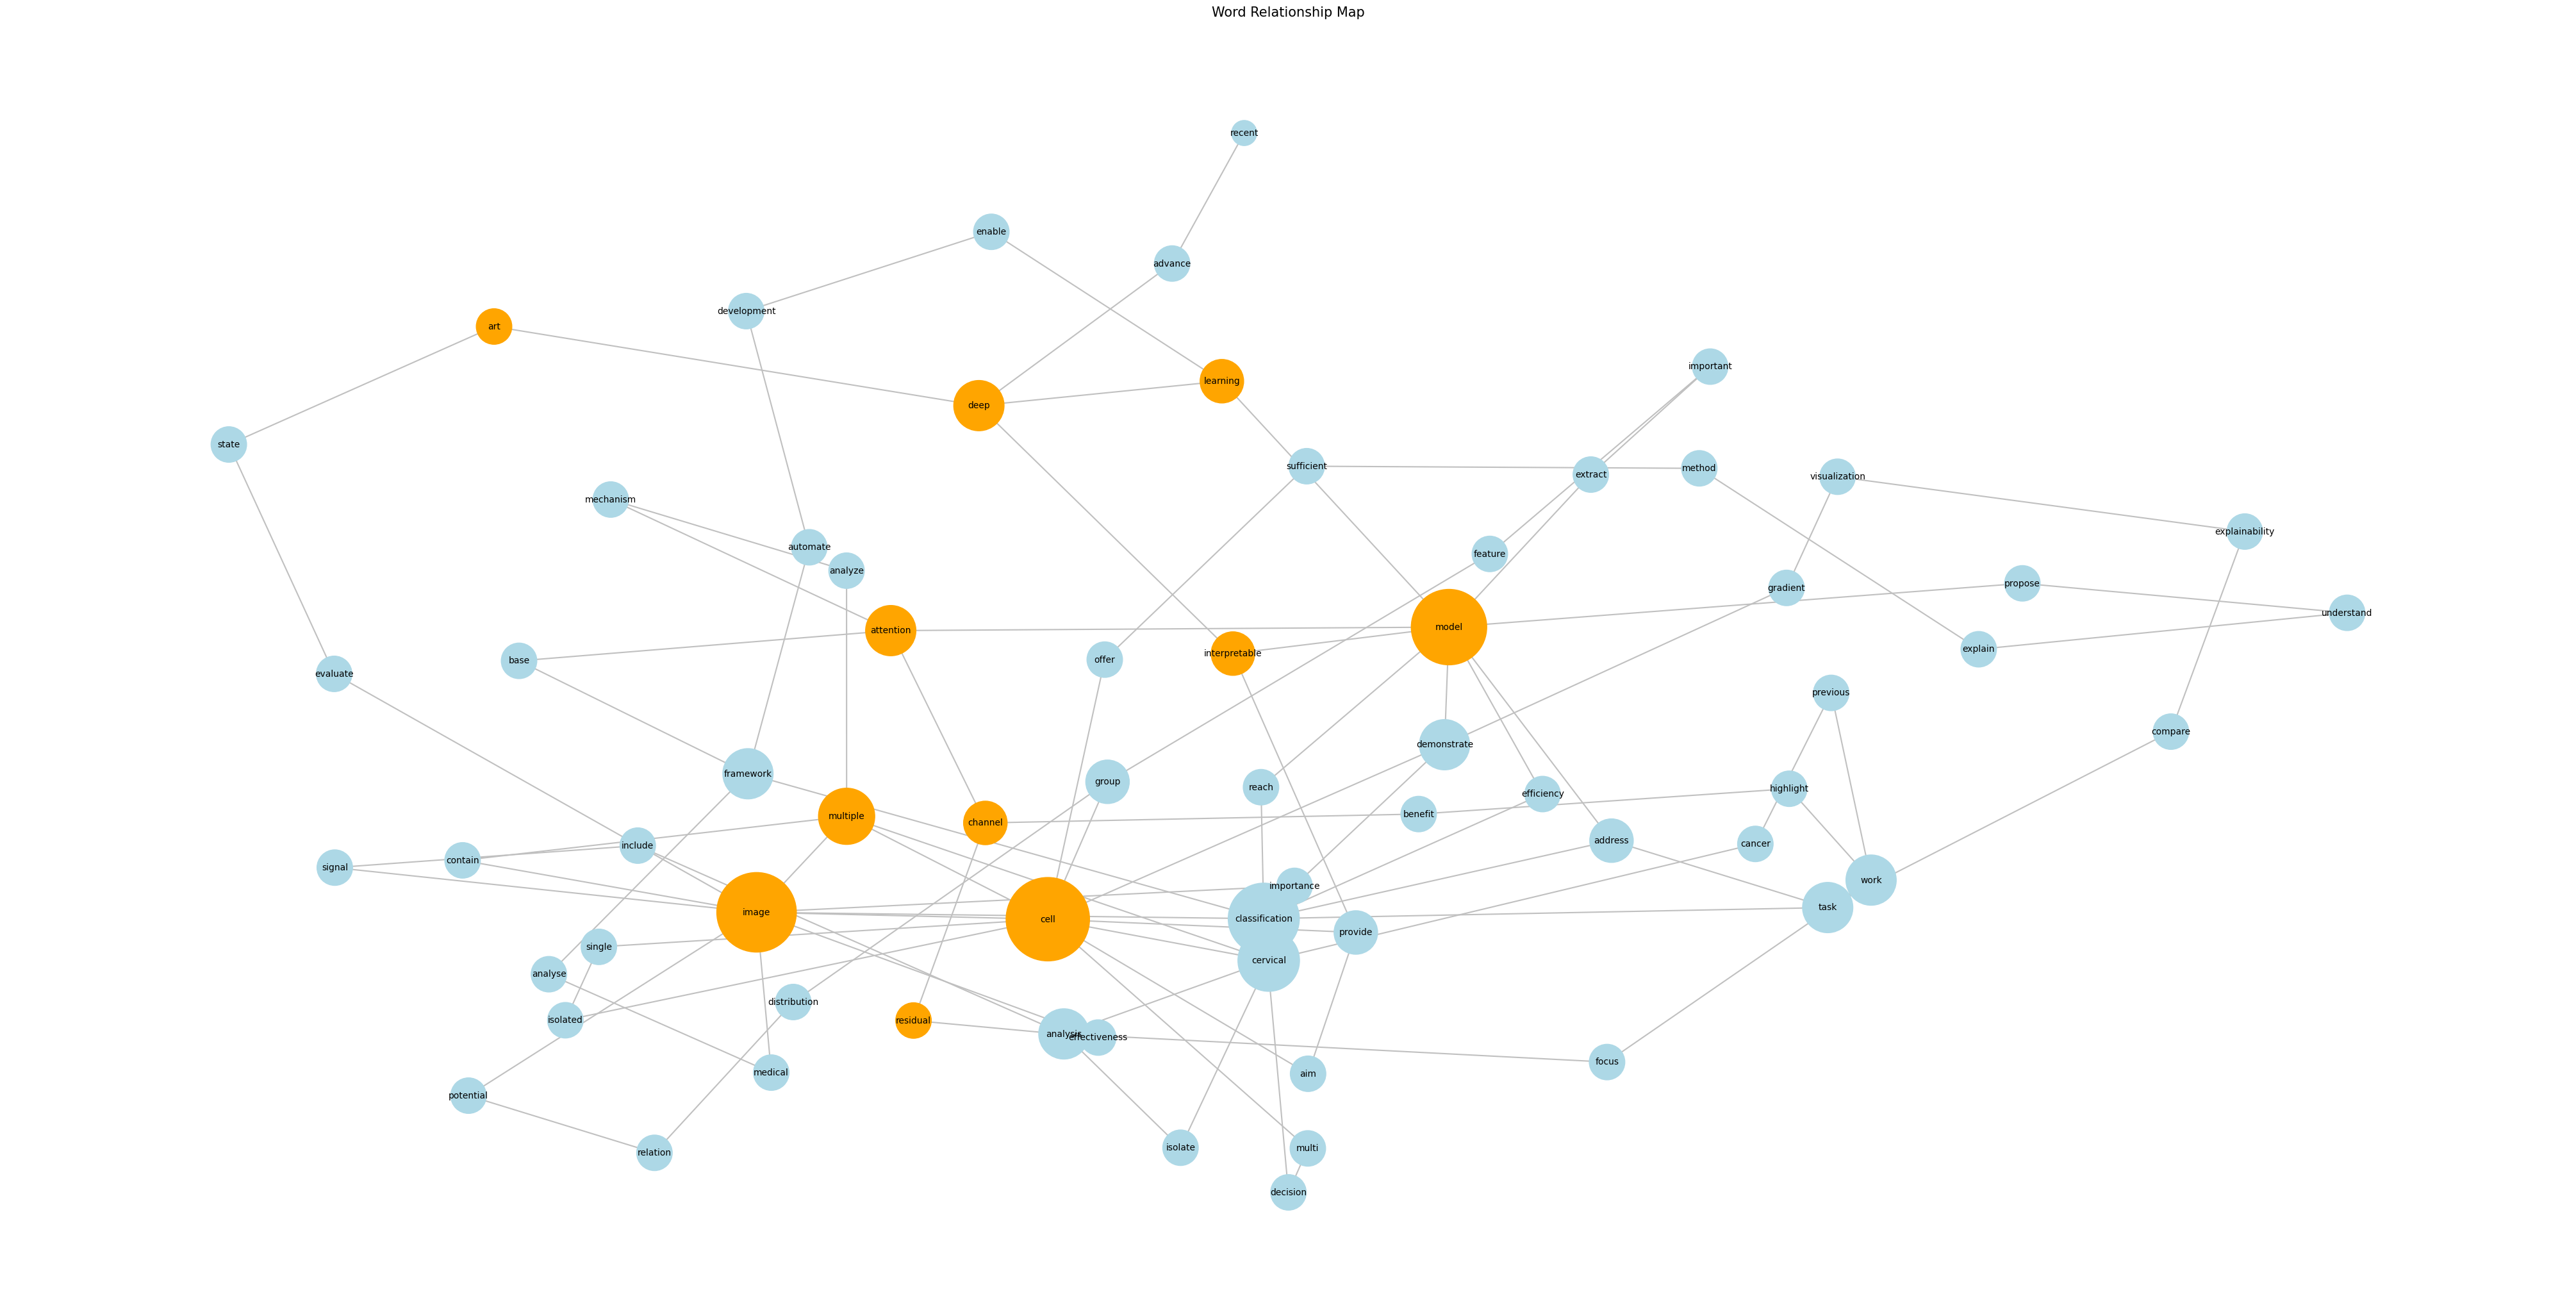

In [ ]:
doc = nlp(sample_text)

words = [token.lemma_.lower() for token in doc 
         if not token.is_stop and not token.is_punct and not token.is_space]

G = nx.Graph()

for i in range(len(words) - 1):
    if words[i] != words[i+1]:
        G.add_edge(words[i], words[i+1])

plt.figure(figsize=(40, 20))
pos = nx.spring_layout(G, k=0.4, iterations=50, seed=42) 

keyword_set = {word.lower() for phrase in extracted_keywords for word in phrase.split()}
node_colors = ['orange' if n in keyword_set else 'lightblue' for n in G.nodes()]
node_sizes = [G.degree(n) * 800 for n in G.nodes()]

nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=node_sizes, 
        edge_color='silver', 
        font_size=10, 
        width=1.5)

plt.title(f"Word Relationship Map", fontsize=15)
plt.show()

### SGRank Algorithm

Applies SGRank (a statistically enhanced version of TextRank) to the same abstract. Prints the summary and top 5 keyphrases.

In [ ]:
def extract_pagerank_keywords(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []
    
    doc = nlp(text)
    results = keyterms.sgrank(doc, normalize="lemma", topn=5)
    return [term for term, score in results]

print("Extracting keywords for sample...")
sample_df['pagerank_keywords'] = sample_df['summary'].apply(extract_pagerank_keywords)

sample_text = sample_df.iloc[0]['summary']
extracted_keywords = sample_df.iloc[0]['pagerank_keywords']

print("\n--- Sample Summary ---")
print(sample_text)
print("\n--- Extracted Keywords ---")
print(extracted_keywords)

Extracting keywords for sample...

--- Sample Summary ---
Recent advances in deep learning have enabled the development of automated
frameworks for analysing medical images and signals, including analysis of
cervical cancer. Many previous works focus on the analysis of isolated cervical
cells, or do not offer sufficient methods to explain and understand how the
proposed models reach their classification decisions on multi-cell images.
Here, we evaluate various state-of-the-art deep learning models and
attention-based frameworks for the classification of images of multiple
cervical cells. As we aim to provide interpretable deep learning models to
address this task, we also compare their explainability through the
visualization of their gradients. We demonstrate the importance of using images
that contain multiple cells over using isolated single-cell images. We show the
effectiveness of the residual channel attention model for extracting important
features from a group of cells, and dem

Builds and visualizes another word co-occurrence graph, again highlighting the SGRank keywords.

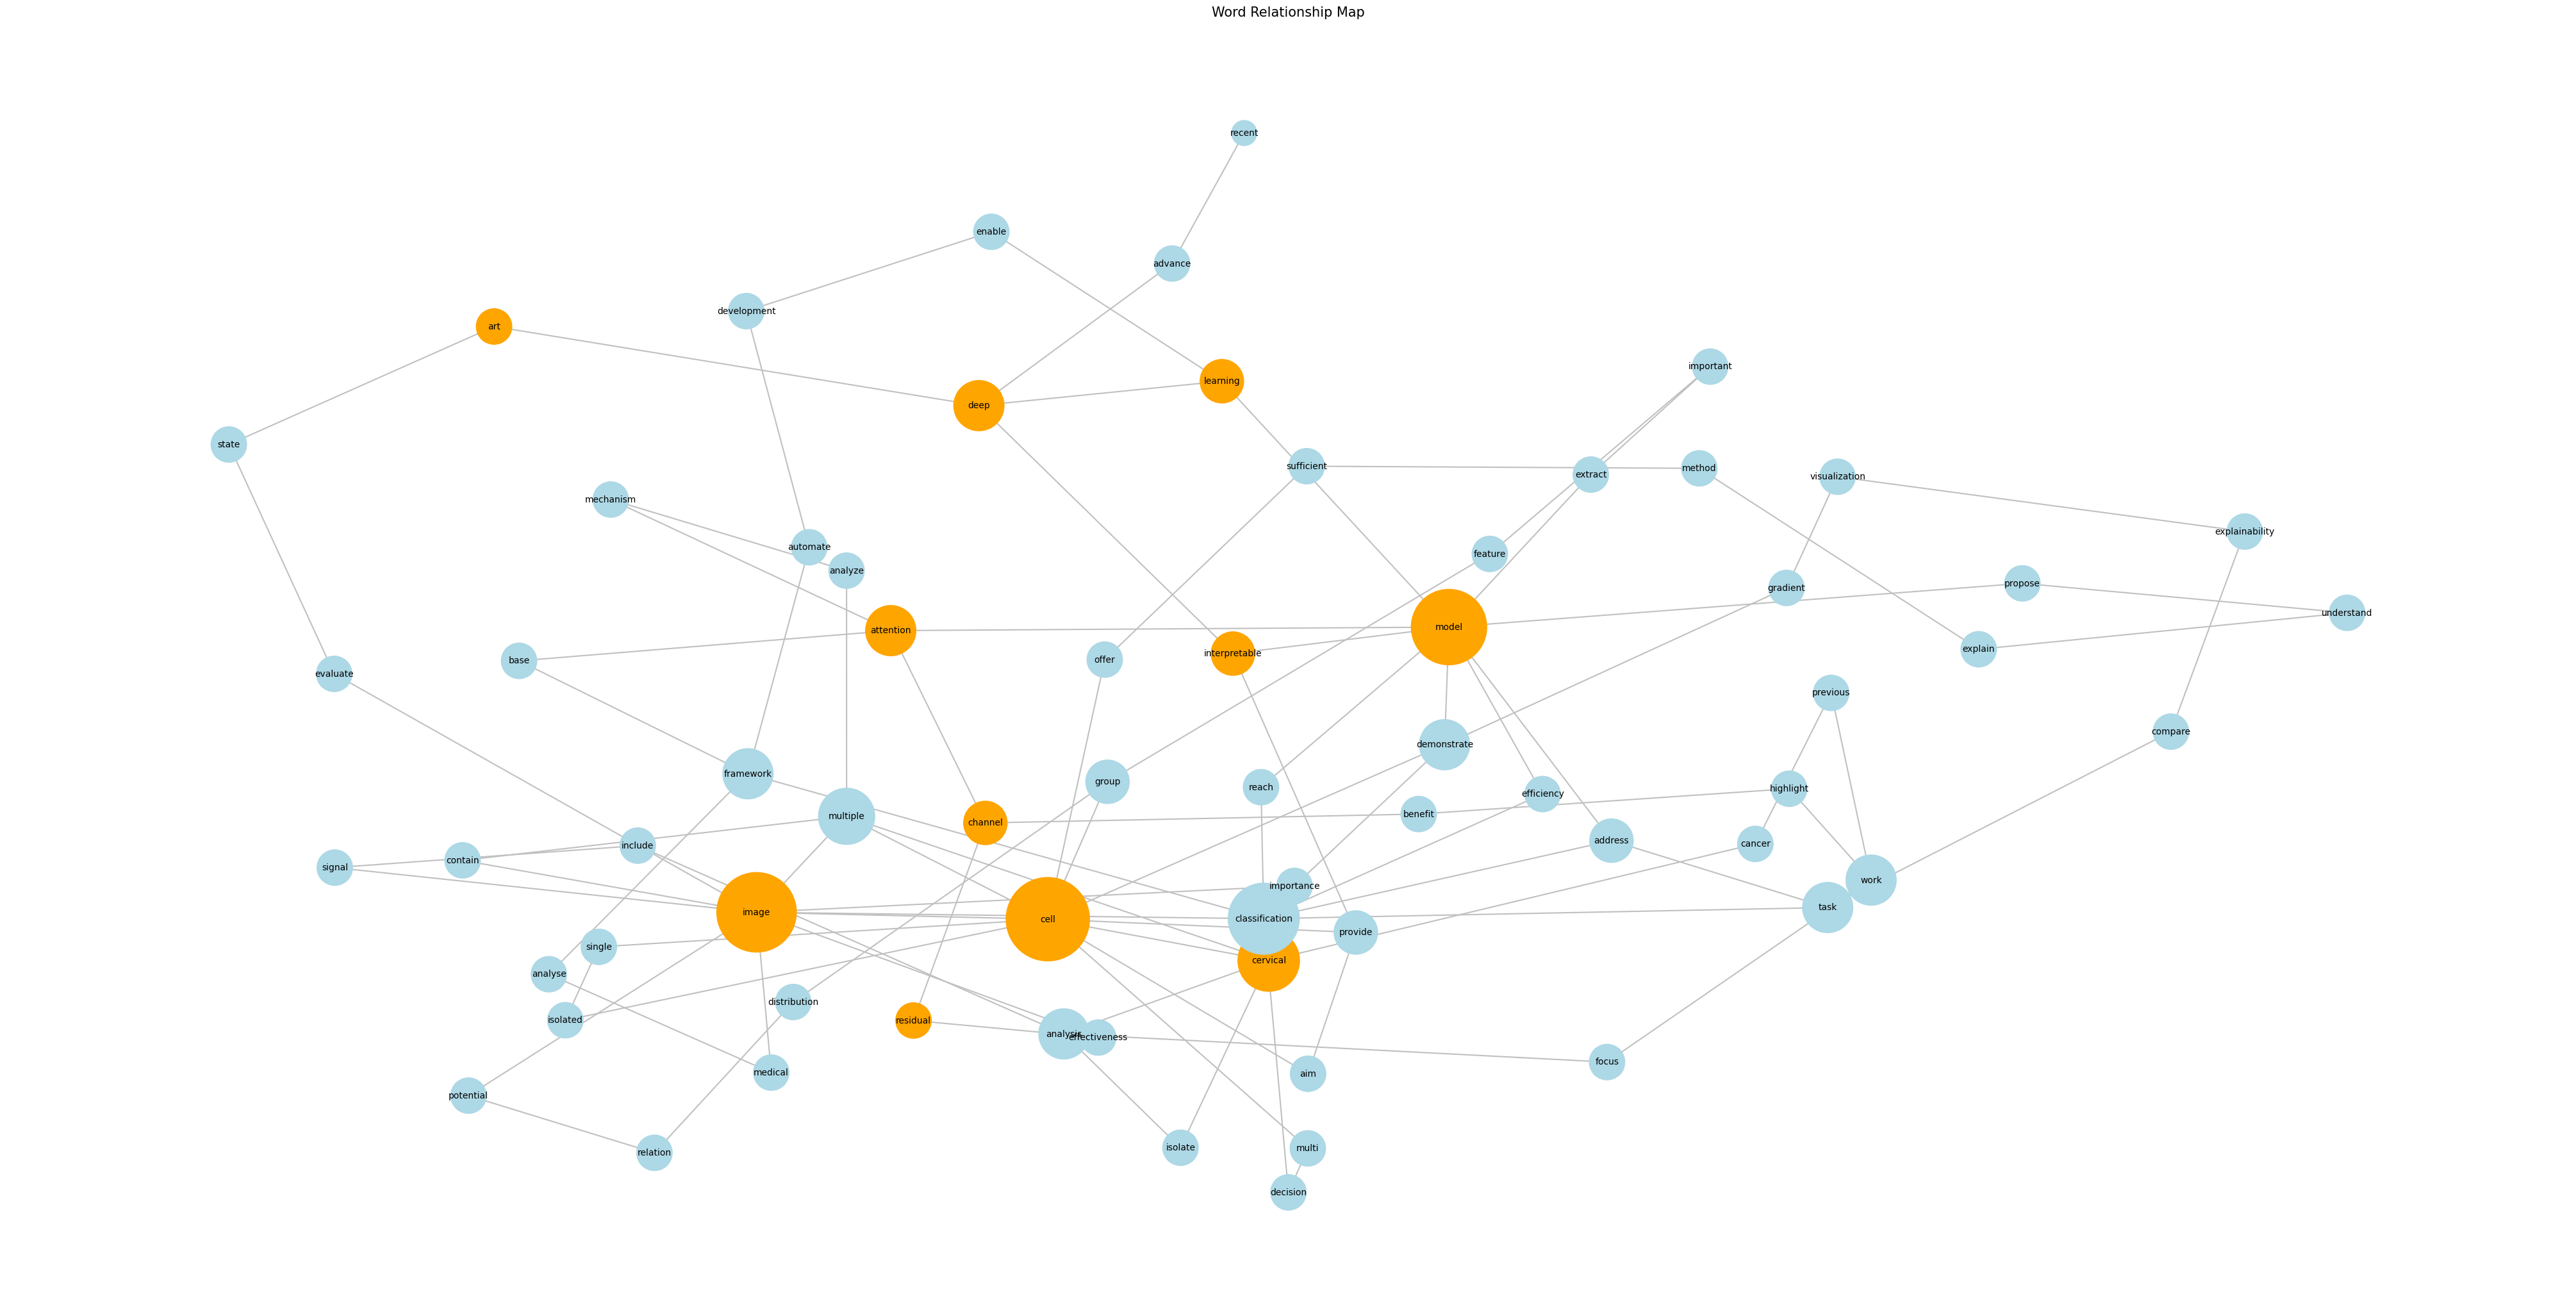

In [ ]:
doc = nlp(sample_text)

words = [token.lemma_.lower() for token in doc 
         if not token.is_stop and not token.is_punct and not token.is_space]

G = nx.Graph()

for i in range(len(words) - 1):
    if words[i] != words[i+1]:
        G.add_edge(words[i], words[i+1])

plt.figure(figsize=(40, 20))
pos = nx.spring_layout(G, k=0.4, iterations=50, seed=42) 

keyword_set = {word.lower() for phrase in extracted_keywords for word in phrase.split()}
node_colors = ['orange' if n in keyword_set else 'lightblue' for n in G.nodes()]
node_sizes = [G.degree(n) * 800 for n in G.nodes()]

nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=node_sizes, 
        edge_color='silver', 
        font_size=10,
        width=1.5)

plt.title(f"Word Relationship Map", fontsize=15)
plt.show()

### TextRank Vs. SGRank Result Comparison

In [ ]:
text_input = sample_df.iloc[0]['summary'] 
doc = nlp(text_input)

tr_results = keyterms.textrank(doc, normalize="lemma", topn=10)
sg_results = keyterms.sgrank(doc, normalize="lemma", topn=10)

df_tr = pd.DataFrame(tr_results, columns=['Keyword', 'TextRank Score'])
df_sg = pd.DataFrame(sg_results, columns=['Keyword', 'SGRank Score'])

df_combined = pd.merge(df_tr, df_sg, on='Keyword', how='inner')

df_combined

,Keyword,TextRank Score,SGRank Score
0,interpretable deep learning model,0.051582,0.099261
1,residual channel attention model,0.050358,0.129442
2,art deep learning model,0.049440,0.070958
3,cell image,0.037343,0.135584
4,cervical cell,0.031176,0.065214
5,classification decision,0.019577,0.028294


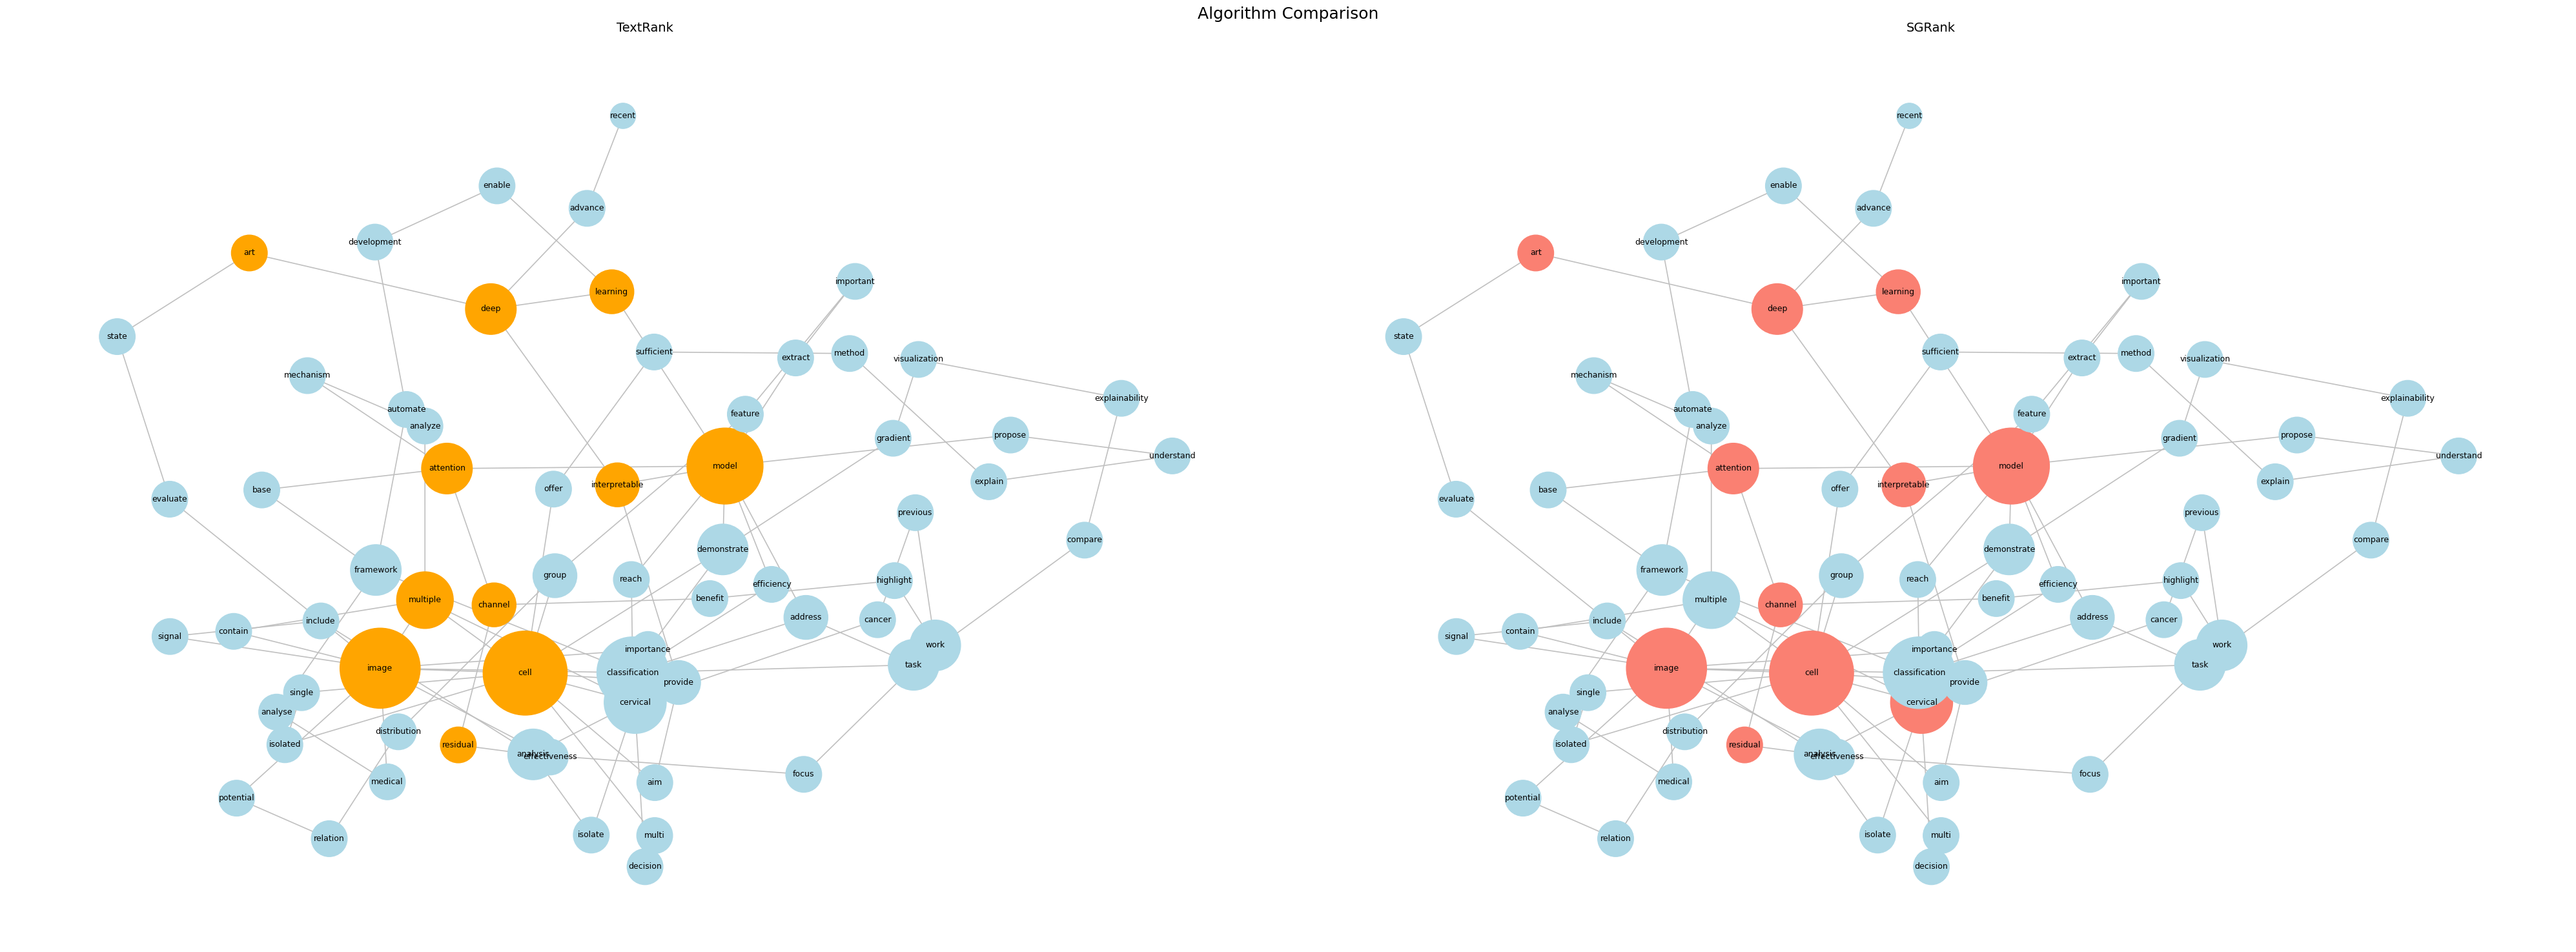

In [ ]:
tr_keywords = [term for term, score in keyterms.textrank(doc, normalize="lemma", topn=5)]
tr_set = {word.lower() for phrase in tr_keywords for word in phrase.split()}

sg_keywords = [term for term, score in keyterms.sgrank(doc, normalize="lemma", topn=5)]
sg_set = {word.lower() for phrase in sg_keywords for word in phrase.split()}

words = [token.lemma_.lower() for token in doc 
         if not token.is_stop and not token.is_punct and not token.is_space]

G = nx.Graph()
for i in range(len(words) - 1):
    if words[i] != words[i+1]:
        G.add_edge(words[i], words[i+1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 15))
pos = nx.spring_layout(G, k=0.4, iterations=50, seed=42)
node_sizes = [G.degree(n) * 800 for n in G.nodes()]

tr_colors = ['orange' if n in tr_set else 'lightblue' for n in G.nodes()]
nx.draw(G, pos, ax=ax1, with_labels=True, node_color=tr_colors, 
        node_size=node_sizes, edge_color='silver', font_size=9, width=1.2)
ax1.set_title(f"TextRank", fontsize=14)

sg_colors = ['salmon' if n in sg_set else 'lightblue' for n in G.nodes()]
nx.draw(G, pos, ax=ax2, with_labels=True, node_color=sg_colors, 
        node_size=node_sizes, edge_color='silver', font_size=9, width=1.2)
ax2.set_title(f"SGRank", fontsize=14)

plt.suptitle(f"Algorithm Comparison", fontsize=18)
plt.tight_layout()
plt.show()

# Conclusion

This implementation successfully demonstrates the effectiveness of graph-based unsupervised keyword extraction using TextRank and SGRank on arXiv scientific abstracts. TextRank provides a solid baseline by relying purely on word co-occurrence and centrality, producing coherent keyphrases that capture global document themes. SGRank consistently outperforms it in precision for technical texts by integrating positional and frequency-based signals, resulting in higher-ranked discriminative phrases (e.g., full model names over partial ones) as evidenced by score tables and graph visualizations. The knowledge graphs effectively illustrate how extracted keywords anchor central clusters in the word network, offering intuitive interpretability. Overall, these methods prove highly valuable for topic discovery and summarization in research literature, requiring no labeled data and scaling well to domain-specific corpora. This work highlights the continued relevance of classic graph-based NLP techniques in modern scientific text analysis.

# References
- [Textacy](https://textacy.readthedocs.io/en/0.12.0/api_reference/extract.html#module-textacy.extract.keyterms.sgrank)
- [Geeksforgeeks](https://www.geeksforgeeks.org/nlp/information-extraction-in-nlp/)
- [Wikipedia : Information extraction](https://en.wikipedia.org/wiki/Information_extraction)